## Transfer Learning
Transfer learning is a machine learning technique where a model developed for a particular task is reused as the starting point for a model on a second task. It leverages the knowledge gained from the first task to improve the performance of the second task, especially when the second task has limited data. This approach is particularly effective in deep learning, where large models can be pre-trained on vast datasets and then fine-tuned for specific applications.

Reference: https://www.geeksforgeeks.org/machine-learning/ml-introduction-to-transfer-learning/

The process of Transfer Learning is:

- Start with a pre-trained model which is already trained on a large dataset for a specific task (classification or regression).
- This model already had access to the general, low-level to complex features and patterns from the dataset it is trained on. Thus, instead of training a new model from scratch, we reuse a **pre-trained model** for related tasks (similar datasets) → At this stage the **pre-trained model becomes the base model.**
- Within the base model (previously known as the **pre-trained model)**, there are layers that have processed data to learn patterns or relationships (e.g., hierarchical representations of the data). The transfer layers (used by the Transfer Learning model) will not use all of them, but it opts for layers within the base model that hold generic information applicable to both the original and new tasks → **Reusable Knowledge: O**nly keep those features or knowledge that are meaningful, important.
- In many cases, the transferred layers are **frozen**, meaning their parameters are not updated during training. This preserves the knowledge already learned from the large dataset and prevents overfitting when the new dataset is small.
- Finally, the selected layers are **fine-tuned** with data from the new task. This process helps retain the pre-trained knowledge while adjusting parameters to meet the specific requirements of the new task, improving accuracy and adaptability.

Basically, Transfer Learning allows us to leverage the power of pre-trained models, which have already learned useful features from large datasets, and apply that knowledge to new tasks with limited data, leading to faster training and improved performance.

The MINST dataset is a collection of 70,000 images of handwritten digits (0-9) that are commonly used for training and testing machine learning models in the field of computer vision. The dataset is divided into a training set of 60,000 images and a test set of 10,000 images. Each image is a 28x28 pixel grayscale image, and the corresponding labels indicate the digit represented in the image. The MNIST dataset is widely used for benchmarking algorithms in image classification tasks and serves as a standard dataset for evaluating the performance of various machine learning models.

This dataset is ideal to demonstrate transfer learning because it is a well-known dataset with a large number of samples, making it suitable for training deep learning models. Additionally, the simplicity of the images (handwritten digits) allows for quick experimentation and understanding of the transfer learning process. By using a pre-trained model on a similar task (e.g., image classification), we can effectively apply transfer learning to achieve good performance on the MNIST dataset, even with limited training data.

1. **Preparing the Dataset**

Since MobileNetV2 is pre-trained on three-channel RGB images of size 224x224, we make a few adjustments to match its expected input shape:
- Reshape the images from grayscale (28x28, 1 channel) to RGB (28x28, 3 channels).
- Resize images to 32x32 pixels, aligning with our model’s configuration.
- Normalize pixel values to fall between 0 and 1 by dividing by 255.


In [4]:
!pip install tensorflow


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [5]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import tensorflow as tf
import numpy as np

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

train_images = np.stack([train_images]*3, axis=-1) / 255.0
test_images = np.stack([test_images]*3, axis=-1) / 255.0

train_images = tf.image.resize(train_images, [32, 32])
test_images = tf.image.resize(test_images, [32, 32])

train_labels = to_categorical(train_labels, 10)
test_labels = to_categorical(test_labels, 10)

print("Training data shape:", train_images.shape, train_labels.shape)
print("Testing data shape:", test_images.shape, test_labels.shape)

Training data shape: (60000, 32, 32, 3) (60000, 10)
Testing data shape: (10000, 32, 32, 3) (10000, 10)


2. **Building, training and evaluating the Model**

We load MobileNetV2 with pre-trained weights from ImageNet excluding the fully connected top layers to customize for our 10-class classification task:

- Freeze the base model to retain learned features and avoid overfitting.
- Add a global average pooling layer to reduce model complexity.
- Add a dense layer with softmax activation for the output classes.

Finally, we compile the model with an appropriate optimizer and loss function for multi-class classification, and train it on the MNIST dataset. This approach allows us to leverage the powerful feature extraction capabilities of MobileNetV2 while adapting it to our specific task of digit classification.

Then we evaluate the model on the test set to assess its performance.

In [6]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
base_model.trainable = False  # Freeze base model

inputs = Input(shape=(32, 32, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
outputs = Dense(10, activation='softmax')(x)
model = Model(inputs, outputs)

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(train_images, train_labels, epochs=5, batch_size=64, validation_split=0.2)

/var/folders/gc/49grx5f90nv3f12yh4jhhf740000gn/T/ipykernel_7247/1849962026.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(32, 32, 3))


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.4839 - loss: 1.7416 - val_accuracy: 0.5710 - val_loss: 1.4478
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.5892 - loss: 1.3461 - val_accuracy: 0.6184 - val_loss: 1.2473
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.6207 - loss: 1.2113 - val_accuracy: 0.6382 - val_loss: 1.1533
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.6366 - loss: 1.1402 - val_accuracy: 0.6489 - val_loss: 1.0992
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.6458 - loss: 1.0964 - val_accuracy: 0.6549 - val_loss: 1.0649


3. **Fine-tuning the Model**

After training the model with the frozen base, we can unfreeze some of the layers in the base model to allow fine-tuning. This process involves:
- Unfreezing the top layers of the base model while keeping the earlier layers frozen to retain the general features learned from ImageNet.
- Recompiling the model with a lower learning rate to prevent large updates to the weights, which could disrupt the learned features.
- Continuing training on the MNIST dataset to further improve the model's performance by allowing it to adapt more closely to the specific characteristics of the MNIST data while still leveraging the pre-trained features from MobileNetV2.

Finally, we evaluate the fine-tuned model on the test set to see if there is an improvement in performance compared to the model with the frozen base -> Test Loss and Test Accuracy.

In [7]:
base_model.trainable = True
for layer in base_model.layers[:100]:
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(train_images, train_labels, epochs=5, validation_split=0.2)

test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f'Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}')

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 42s 25ms/step - accuracy: 0.3442 - loss: 4.1965 - val_accuracy: 0.1567 - val_loss: 6.6254
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 38s 25ms/step - accuracy: 0.5613 - loss: 1.6962 - val_accuracy: 0.3523 - val_loss: 1.9345
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 42s 28ms/step - accuracy: 0.6780 - loss: 1.1339 - val_accuracy: 0.7339 - val_loss: 0.9015
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 42s 28ms/step - accuracy: 0.7497 - loss: 0.8515 - val_accuracy: 0.8287 - val_loss: 0.6264
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 38s 26ms/step - accuracy: 0.8006 - loss: 0.6743 - val_accuracy: 0.8645 - val_loss: 0.5125
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8510 - loss: 0.5679
Test Loss: 0.5679, Test Accuracy: 0.8510


Visualization with confusion matrix and classification report to analyze the performance of the model in more detail, identifying which classes are being predicted correctly and which are being misclassified. This helps in understanding the strengths and weaknesses of the model and can guide further improvements.

In [8]:
from sklearn.metrics import classification_report

y_pred = model.predict(test_images)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(test_labels, axis=1)
print(classification_report(y_true_classes, y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step
              precision    recall  f1-score   support

           0       0.95      0.96      0.95       980
           1       0.96      0.78      0.86      1135
           2       0.75      0.86      0.80      1032
           3       0.77      0.85      0.81      1010
           4       0.81      0.87      0.84       982
           5       0.80      0.79      0.79       892
           6       0.86      0.92      0.89       958
           7       0.91      0.81      0.86      1028
           8       0.88      0.82      0.85       974
           9       0.88      0.85      0.87      1009

    accuracy                           0.85     10000
   macro avg       0.86      0.85      0.85     10000
weighted avg       0.86      0.85      0.85     10000



313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


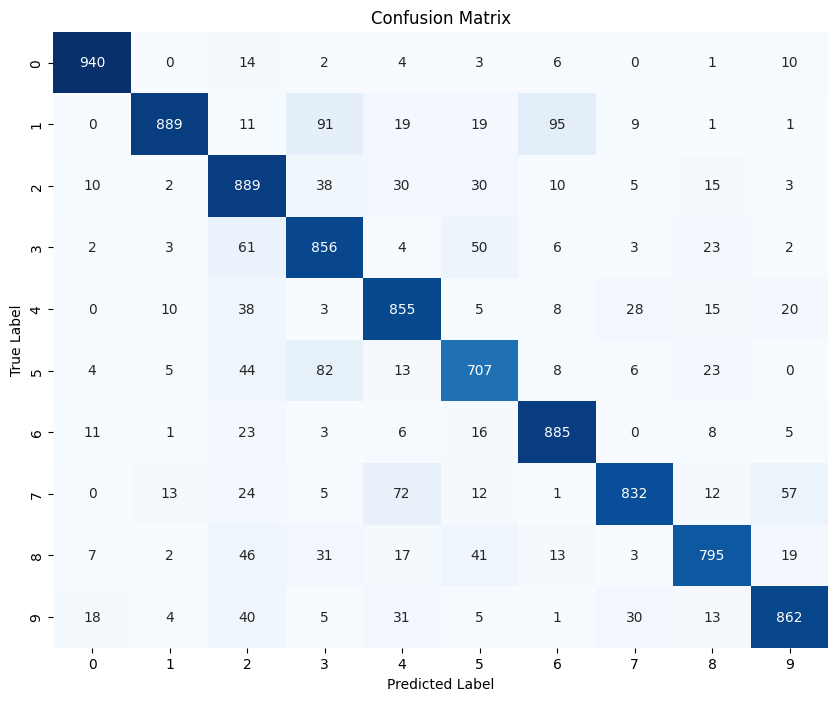

In [9]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

test_predictions = model.predict(test_images)
test_predictions_classes = np.argmax(test_predictions, axis=1)
test_true_classes = np.argmax(test_labels, axis=1)

cm = confusion_matrix(test_true_classes, test_predictions_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

Finally we select a few test images to visualize the model’s predictions against their true labels. This helps us understand how well the model is performing on individual samples and can provide insights into any misclassifications. We can display the images along with their predicted and true labels to see where the model is succeeding and where it may be struggling.

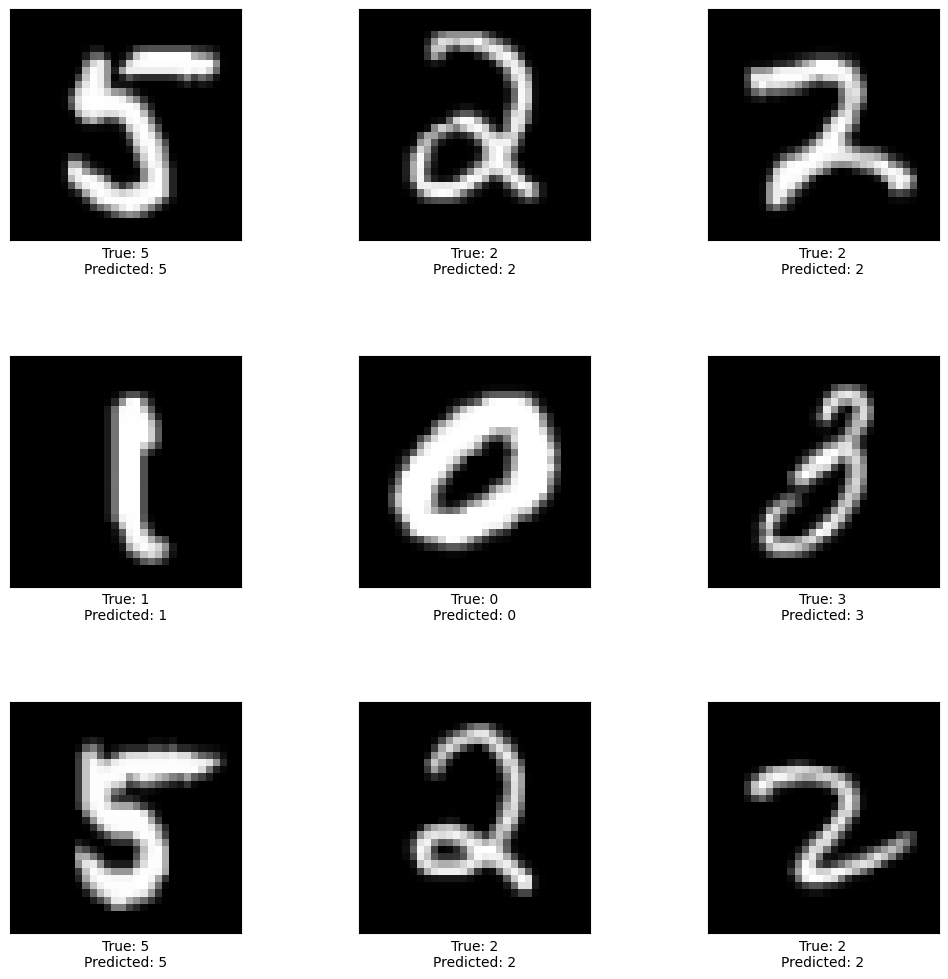

In [10]:
def display_sample(sample_images, sample_labels, sample_predictions):
    fig, axes = plt.subplots(3, 3, figsize=(12, 12))
    fig.subplots_adjust(hspace=0.5, wspace=0.5)

    for i, ax in enumerate(axes.flat):
        ax.imshow(sample_images[i].reshape(32, 32), cmap='gray')
        ax.set_xlabel(f"True: {sample_labels[i]}\nPredicted: {sample_predictions[i]}")
        ax.set_xticks([])
        ax.set_yticks([])

    plt.show()

test_images_gray = np.dot(test_images[...,:3], [0.2989, 0.5870, 0.1140])

random_indices = np.random.choice(len(test_images_gray), 9, replace=False)
sample_images = test_images_gray[random_indices]
sample_labels = test_true_classes[random_indices]
sample_predictions = test_predictions_classes[random_indices]
display_sample(sample_images, sample_labels, sample_predictions)